## step 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
df=pd.read_csv(r"C:\Users\Hp\Desktop\binx_mohammadabuhamed\binx_mohammadabuhamed\week3\day5\bank.csv")
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='str')

## step 2

see the data types


In [2]:
df.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
deposit        str
dtype: object

check the values

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


statistics

In [4]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


information for catigCategorical

In [5]:
df.describe(include='object')

C:\Users\Hp\AppData\Local\Temp\ipykernel_19520\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


see the balance in target

In [6]:
df['deposit'].value_counts(normalize=True)*100

deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64

Customers who subscribed tend to have:

- Longer call durations.

- Higher average balance.

- More previous successful contacts.

In [9]:
df.groupby('deposit').mean(numeric_only=True)

,age,balance,day,duration,campaign,pdays,previous
deposit,,,,,,,
no,40.837391,1280.227141,16.108122,223.130257,2.839264,35.685340,0.528350
yes,41.670070,1804.267915,15.158253,537.294574,2.141047,68.702968,1.170354




The heatmap shows the correlation between numerical features.

Most features have weak correlations. The strongest relationship is between `pdays` and `previous` with a correlation of 0.51, indicating a moderate positive correlation.

Overall, there are no strong correlations between features.

<Axes: >

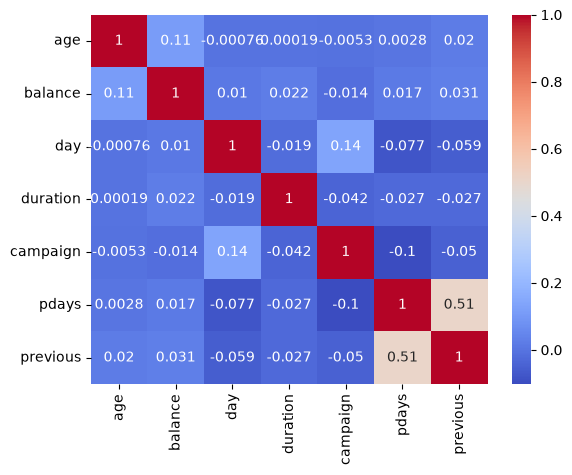

In [10]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,
    annot=True,
    cmap="coolwarm")

comparing between jobs

<Axes: xlabel='job', ylabel='count'>

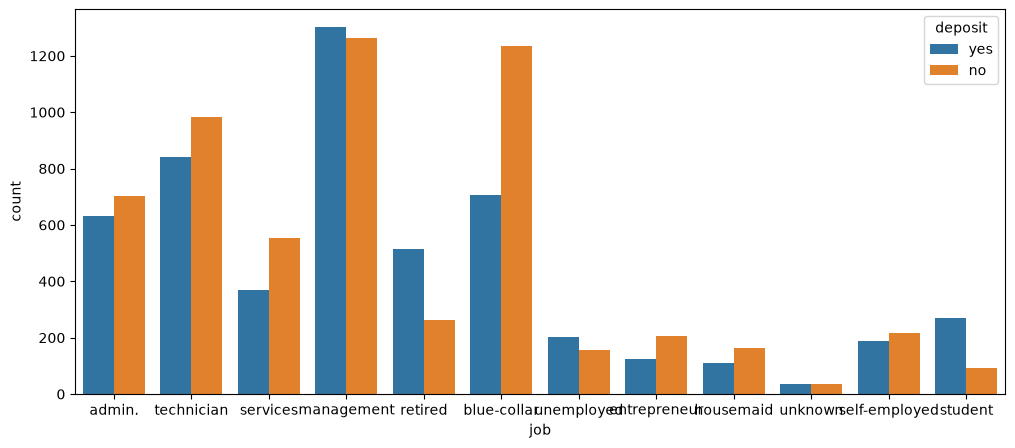

In [11]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="job",
    hue="deposit"
)

delete this columns because we don`t need it

In [12]:
df = df.drop(["day", "month", "contact"], axis=1)

#### EDA done!

### Preprocessing

split in x and y

In [13]:
X = df.drop("deposit", axis=1)

y = df["deposit"]

make y number to make it esair to use

In [14]:
y = y.map({
    "yes": 1,
    "no": 0
})

split data to train and test to scaler it 

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    
)

split columns to 2 types to encode an scale

In [17]:
catcols=X_train.select_dtypes(include='object').columns
numcols=X_train.select_dtypes(exclude='object').columns
catcols

C:\Users\Hp\AppData\Local\Temp\ipykernel_19520\1593286241.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catcols=X_train.select_dtypes(include='object').columns


Index(['job', 'marital', 'education', 'default', 'housing', 'loan',
       'poutcome'],
      dtype='str')



ColumnTransformer applies different transformations based on feature types:

- Numerical columns are scaled using StandardScaler.

- Categorical columns are encoded using OneHotEncoder.



handle_unknown for if wee se something in test we dont see it in train to make it dont stop

In [18]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numcols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), catcols)
    ]
)

scaling and encoding the train data

make preprocessor train on scaling on train data and test do not

In [19]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## step 3

create logisic regression model

In [22]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()

train it

In [24]:
model1.fit(X_train_processed, y_train)
pred1=model1.predict(X_test_processed)

create baseline

In [25]:
from sklearn.dummy import DummyClassifier
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_processed, y_train)
baseline_pred = baseline.predict(X_test_processed)

create SVM model

In [26]:
from sklearn.svm import SVC
model2=SVC(kernel='rbf',probability=True)
model2.fit(X_train_processed,y_train)
pred2=model2.predict(X_test_processed)

c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


create a random forest model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier(n_estimators=100,random_state=42)
model3.fit(X_train_processed,y_train)
pred3=model3.predict(X_test_processed)

compare the models and the SVM is the best

In [35]:
from sklearn.metrics import accuracy_score
res=pd.DataFrame({
    'model':['logistic',
     'SVM',
     'random_forest',
     'baselinee'
     ]
    ,
   'accuacy': [
        accuracy_score(y_test,pred1)*100,
        accuracy_score(y_test,pred2)*100,
        accuracy_score(y_test,pred3)*100,
        accuracy_score(y_test,baseline_pred)*100
    ]
})
res

,model,accuacy
0,logistic,79.489476
1,SVM,79.758173
2,random_forest,79.489476
3,baselinee,52.216749


## step 4

I selected SVM as the best model for the following reasons:

Highest accuracy: SVM achieved the highest accuracy among the three models (79.76%), although the margin over Logistic Regression and Random Forest is small (~0.27%).

Comparison against the baseline: All three models clearly outperform the baseline (52.22%), by roughly 27 percentage points. This confirms that the models are genuinely learning patterns from the data rather than guessing.

Close performance across models: The fact that Logistic Regression, SVM, and Random Forest perform almost identically (within 0.3%) suggests the current feature set has a performance ceiling, and the difference between them is likely not statistically significant.